Total original track points: 16526
Track points 1960-2024: 16526
Track points Jun-Oct: 15667
Track points with wind_category 1-3: 15667
Track points with valid wind speed: 15040
MJO active days (amplitude ≥ 1) records: 14550
Available MJO active dates: 14550
Track points matched to MJO active days: 8571
ACE calculation verification example
Typhoon code : 6001
Date & time  : 1960-06-02 06:00:00
Wind (m/s)   : 9.5
Wind (kt)    : 18.5  (conversion: 1 m/s = 1.94384 kt)
ACE contrib  : 0.034101  (formula: (wind_kt)^2 / 10000)
Phase group  : Phases 7-8

Total ACE by phase group (unit: 10⁴ kt²):
Phases 1-2  : 403.11
Phases 3-4  : 364.14
Phases 5-6  : 1278.43
Phases 7-8  : 616.37

Total ACE : 2662.04


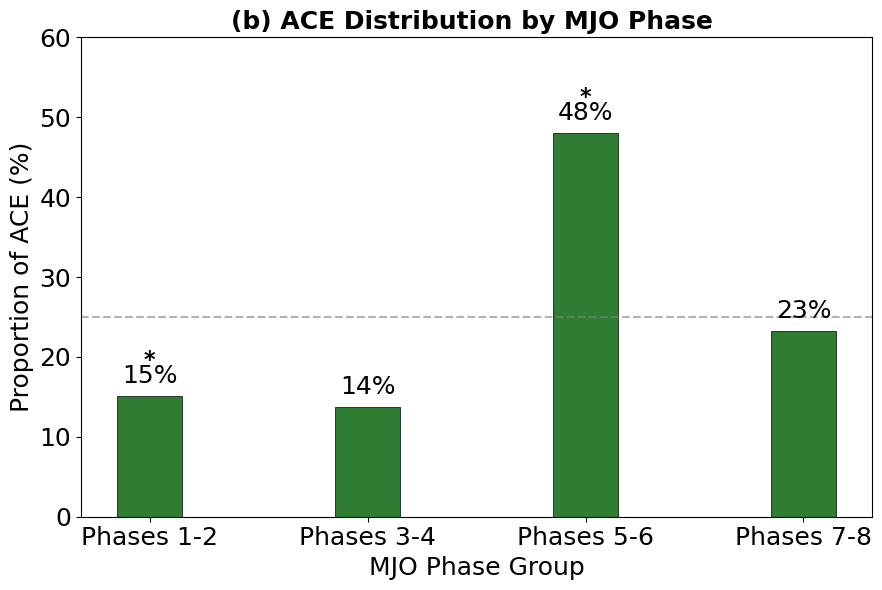

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ==================== Global path configuration ====================
INFO_PATH = "./typhoon_output/landfall_typhoons_info.csv"
TRACKS_PATH = "./typhoon_output/landfall_typhoons_tracks.csv"
MJO_PATH = "./ERA5 MJO (1950-2024).csv"

# Wind speed conversion constant: 1 m/s = 1.94384 kt
MS_TO_KT = 1.94384

# MJO phase group definitions
PHASE_GROUPS = {
    (1,2): 'Phases 1-2',
    (3,4): 'Phases 3-4',
    (5,6): 'Phases 5-6',
    (7,8): 'Phases 7-8'
}
GROUP_ORDER = ['Phases 1-2', 'Phases 3-4', 'Phases 5-6', 'Phases 7-8']

# %% [markdown]
# ### 3.1 Load and preprocess typhoon track data

# %%
# Read track data, add 4-digit string code, month
tracks_df = pd.read_csv(TRACKS_PATH)
tracks_df['TIME'] = pd.to_datetime(tracks_df['TIME'])
tracks_df['code_str'] = tracks_df['chinese_code'].apply(lambda x: f"{x:04d}")
tracks_df['year'] = tracks_df['TIME'].dt.year
tracks_df['month'] = tracks_df['TIME'].dt.month
tracks_df['date'] = tracks_df['TIME'].dt.date

print(f"Total original track points: {len(tracks_df)}")

# Filter years 1960-2024
tracks_df = tracks_df[(tracks_df['year'] >= 1960) & (tracks_df['year'] <= 2024)]
print(f"Track points 1960-2024: {len(tracks_df)}")

# Filter months 6-10
tracks_df = tracks_df[tracks_df['month'].between(6,10)]
print(f"Track points Jun-Oct: {len(tracks_df)}")

# Filter typhoon intensity categories 1,2,3 (Storms, TCs, Super TCs)
tracks_df = tracks_df[tracks_df['wind_category'].isin([1,2,3])]
print(f"Track points with wind_category 1-3: {len(tracks_df)}")

# Ensure wind speed not null and > 0 (required for ACE calculation)
tracks_df = tracks_df.dropna(subset=['WND'])
tracks_df = tracks_df[tracks_df['WND'] > 0]
print(f"Track points with valid wind speed: {len(tracks_df)}")

# %% [markdown]
# ### 3.2 Load and preprocess MJO data (keep only active days with amplitude ≥ 1)

# %%
mjo_df = pd.read_csv(MJO_PATH)
mjo_df['date'] = pd.to_datetime(mjo_df['date']).dt.date

# Time range 1960-2024
mjo_df = mjo_df[(mjo_df['date'] >= pd.to_datetime('1960-01-01').date()) & 
                (mjo_df['date'] <= pd.to_datetime('2024-12-31').date())]

# Keep only active events with amplitude ≥ 1
mjo_df = mjo_df[mjo_df['amplitude'] >= 1].copy()
print(f"MJO active days (amplitude ≥ 1) records: {len(mjo_df)}")

def phase_to_group(phase):
    """Map phases 1-8 to four groups"""
    if pd.isna(phase):
        return None
    p = int(phase)
    if p in [1,2]:
        return 'Phases 1-2'
    elif p in [3,4]:
        return 'Phases 3-4'
    elif p in [5,6]:
        return 'Phases 5-6'
    elif p in [7,8]:
        return 'Phases 7-8'
    else:
        return None

mjo_df['phase_group'] = mjo_df['phase'].apply(phase_to_group)
mjo_df = mjo_df.dropna(subset=['phase_group'])

# Build date -> phase group dictionary (only active days)
date_to_phase = pd.Series(mjo_df['phase_group'].values, index=mjo_df['date']).to_dict()
print(f"Available MJO active dates: {len(date_to_phase)}")

# %% [markdown]
# ### 3.3 Match dates and compute ACE contribution per track point

# %%
# Add phase group to track points (keep only records matching MJO active days)
tracks_df['phase_group'] = tracks_df['date'].map(date_to_phase)
tracks_df = tracks_df.dropna(subset=['phase_group'])
print(f"Track points matched to MJO active days: {len(tracks_df)}")

# Calculate ACE contribution for each point
# Formula: ACE_point = (wind_speed(kt))^2 / 10000
tracks_df['wnd_kt'] = tracks_df['WND'] * MS_TO_KT
tracks_df['ace_contrib'] = (tracks_df['wnd_kt'] ** 2) / 10000

# %% [markdown]
# #### **ACE Calculation Verification (print a sample)**

# %%
# Select first track point for verification
sample = tracks_df.iloc[0]
print("="*60)
print("ACE calculation verification example")
print("="*60)
print(f"Typhoon code : {sample['code_str']}")
print(f"Date & time  : {sample['TIME']}")
print(f"Wind (m/s)   : {sample['WND']:.1f}")
print(f"Wind (kt)    : {sample['wnd_kt']:.1f}  (conversion: 1 m/s = {MS_TO_KT} kt)")
print(f"ACE contrib  : {sample['ace_contrib']:.6f}  (formula: (wind_kt)^2 / 10000)")
print(f"Phase group  : {sample['phase_group']}")
print("="*60)

# %% [markdown]
# ### 3.4 Summarize total ACE by phase group

# %%
# Group and sum
ace_by_group = tracks_df.groupby('phase_group')['ace_contrib'].sum().reindex(GROUP_ORDER, fill_value=0)
total_ace = ace_by_group.sum()

print("\nTotal ACE by phase group (unit: 10⁴ kt²):")
for group in GROUP_ORDER:
    print(f"{group:12s}: {ace_by_group[group]:.2f}")

print(f"\nTotal ACE : {total_ace:.2f}")

# Calculate percentages
pct_by_group = (ace_by_group / total_ace * 100).round(1)

# %% [markdown]
# ### 3.5 Plot bar chart

# Set up figure
fig, ax = plt.subplots(figsize=(9, 6))

# X-axis positions
x = np.arange(len(GROUP_ORDER))
width = 0.3  # Bar width

# Plot green bars
bars = ax.bar(x, pct_by_group.values, width, color='#2E7D32', edgecolor='black', linewidth=0.5)

# Annotate percentage on top of each bar, and add asterisks above specific bars
for i, (bar, pct) in enumerate(zip(bars, pct_by_group.values)):
    height = bar.get_height()
    x_center = bar.get_x() + bar.get_width() / 2
    y_percent = height + 1  # Position for percentage number
    # Draw percentage number
    ax.text(x_center, y_percent, f'{pct:.0f}%', ha='center', va='bottom', fontsize=18)
    # If first or third bar, add asterisk above
    if i in [0, 2]:
        y_star = y_percent + 2  # Asterisk position slightly higher
        ax.text(x_center, y_star, '*', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Add 25% dashed reference line
ax.axhline(y=25, color='gray', alpha=0.6, linestyle='--', linewidth=1.5, label='_nolegend_')

# Axis labels and title (English)
ax.set_xlabel('MJO Phase Group', fontsize=18)
ax.set_ylabel('Proportion of ACE (%)', fontsize=18)
ax.set_title('(b) ACE Distribution by MJO Phase ', 
             fontsize=18, fontweight='bold')

# X-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER, fontsize=18)

# Y-axis range to leave space for annotations
ax.set_ylim(0, 60)

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# Remove legend, grid, etc.
ax.grid(False)
ax.legend_ = None  # Ensure no legend

plt.tight_layout()
plt.savefig('1b.png', dpi=600, bbox_inches='tight')
plt.show()